In [16]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [17]:
df = pd.read_excel(
    "Data_Model_IoTMLCQ_2024.xlsx"
)

print("Dataset Loaded")
print(df.shape)

df.head()

Dataset Loaded
(4383, 28)


,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable


In [18]:
print(df.columns.tolist())

['Datetime', 'Month', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Month_Num', 'month_x', 'Oxygenation Interventions', 'Corrective Interventions', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 'Precipitation (inches)', 'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Oxygenation Automatic', 'Corrective Measures', 'Thermal Risk Index', 'Low Oxygen Alert', 'Health Status']


In [19]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nHealth Status Distribution")
print(df["Health Status"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Datetime                    4383 non-null   datetime64[us]
 1   Month                       4383 non-null   str           
 2   Average Fish Weight (g)     4383 non-null   float64       
 3   Survival Rate (%)           4383 non-null   float64       
 4   Disease Occurrence (Cases)  4383 non-null   float64       
 5   Temperature (°C)            4383 non-null   float64       
 6   Dissolved Oxygen (mg/L)     4383 non-null   float64       
 7   pH                          4383 non-null   float64       
 8   Turbidity (NTU)             4383 non-null   float64       
 9   Month_Num                   4383 non-null   float64       
 10  month_x                     4383 non-null   float64       
 11  Oxygenation Interventions   4383 non-null   int64         
 12  Cor

In [20]:
df["Datetime"] = pd.to_datetime(
    df["Datetime"]
)

df["Datetime_ts"] = (
    df["Datetime"].astype("int64") // 10**9
)

df.drop(
    columns=["Datetime"],
    inplace=True
)

df.head()

,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,month_x,...,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status,Datetime_ts
0,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,1.0,...,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable,1704067
1,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,1.0,...,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable,1704070
2,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,1.0,...,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable,1704074
3,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,1.0,...,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable,1704078
4,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,1.0,...,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable,1704081


In [21]:
encoders = {}

for col in df.columns:

    if df[col].dtype == "object":

        le = LabelEncoder()

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

        encoders[col] = le

print("Encoding Finished")

Encoding Finished


In [22]:
X = df.drop(
    columns=["Health Status"]
)

y = df["Health Status"]

print("Jumlah Feature :", X.shape[1])

print(X.columns.tolist())

Jumlah Feature : 27
['Month', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Month_Num', 'month_x', 'Oxygenation Interventions', 'Corrective Interventions', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 'Precipitation (inches)', 'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Oxygenation Automatic', 'Corrective Measures', 'Thermal Risk Index', 'Low Oxygen Alert', 'Datetime_ts']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train :", len(X_train))
print("Test  :", len(X_test))

Train : 3506
Test  : 877


In [24]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
X.select_dtypes(include="object").columns

C:\Users\farha\AppData\Local\Temp\ipykernel_13128\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Month', 'Oxygenation Automatic', 'Corrective Measures',
       'Thermal Risk Index', 'Low Oxygen Alert'],
      dtype='str')

In [28]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Month',
    'Oxygenation Automatic',
    'Corrective Measures',
    'Thermal Risk Index',
    'Low Oxygen Alert'
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

print("Encoding selesai")

Encoding selesai


In [29]:
print(
    df.select_dtypes(
        exclude=["number"]
    ).columns
)

Index(['Health Status'], dtype='str')


In [30]:
print(y.dtype)
print(y.unique())

str
<StringArray>
['Stable', 'At Risk']
Length: 2, dtype: str


In [31]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    df["Health Status"]
)

print(np.unique(y))

[0 1]


In [32]:
print(X.dtypes.unique())
print(y.dtype)

[<StringDtype(storage='python', na_value=nan)> dtype('float64')
 dtype('int64')]
int64


In [33]:
X = df.drop(
    columns=["Health Status"]
)

y = df["Health Status"]

print("Jumlah Feature :", X.shape[1])

print(X.columns.tolist())

Jumlah Feature : 27
['Month', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Month_Num', 'month_x', 'Oxygenation Interventions', 'Corrective Interventions', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 'Precipitation (inches)', 'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Oxygenation Automatic', 'Corrective Measures', 'Thermal Risk Index', 'Low Oxygen Alert', 'Datetime_ts']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train :", len(X_train))
print("Test  :", len(X_test))

Train : 3506
Test  : 877


In [35]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [36]:
rf.fit(
    X_train,
    y_train
)

print("Training Finished")

Training Finished


In [37]:
y_pred = rf.predict(
    X_test
)

y_pred[:10]

array(['Stable', 'At Risk', 'Stable', 'Stable', 'At Risk', 'Stable',
       'Stable', 'Stable', 'Stable', 'Stable'], dtype=object)

In [38]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100, 4),
    "%"
)

Accuracy: 100.0 %


In [39]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00       141
      Stable       1.00      1.00      1.00       736

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [40]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(scores)

print(
    "Mean Accuracy:",
    scores.mean()
)

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


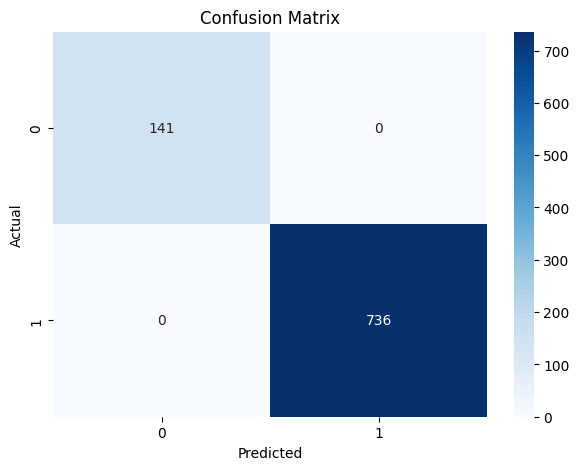

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [42]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Temperature (°C),0.202092
24,Thermal Risk Index,0.189071
1,Average Fish Weight (g),0.163542
2,Survival Rate (%),0.112224
5,Dissolved Oxygen (mg/L),0.095656
6,pH,0.046366
26,Datetime_ts,0.034009
16,month_y,0.027560
9,month_x,0.027105
15,Precipitation (inches),0.026205


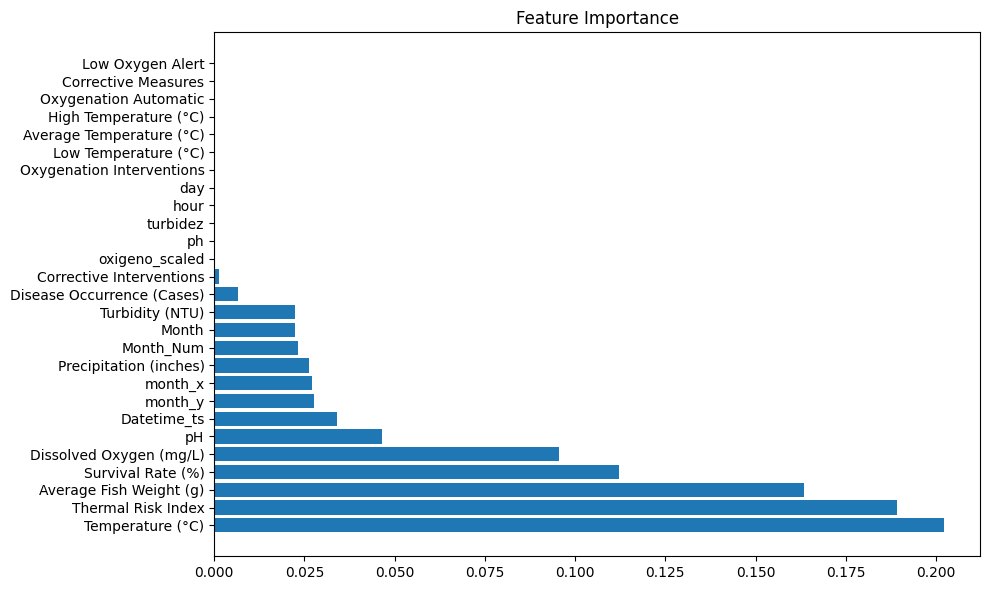

In [43]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.tight_layout()

plt.show()

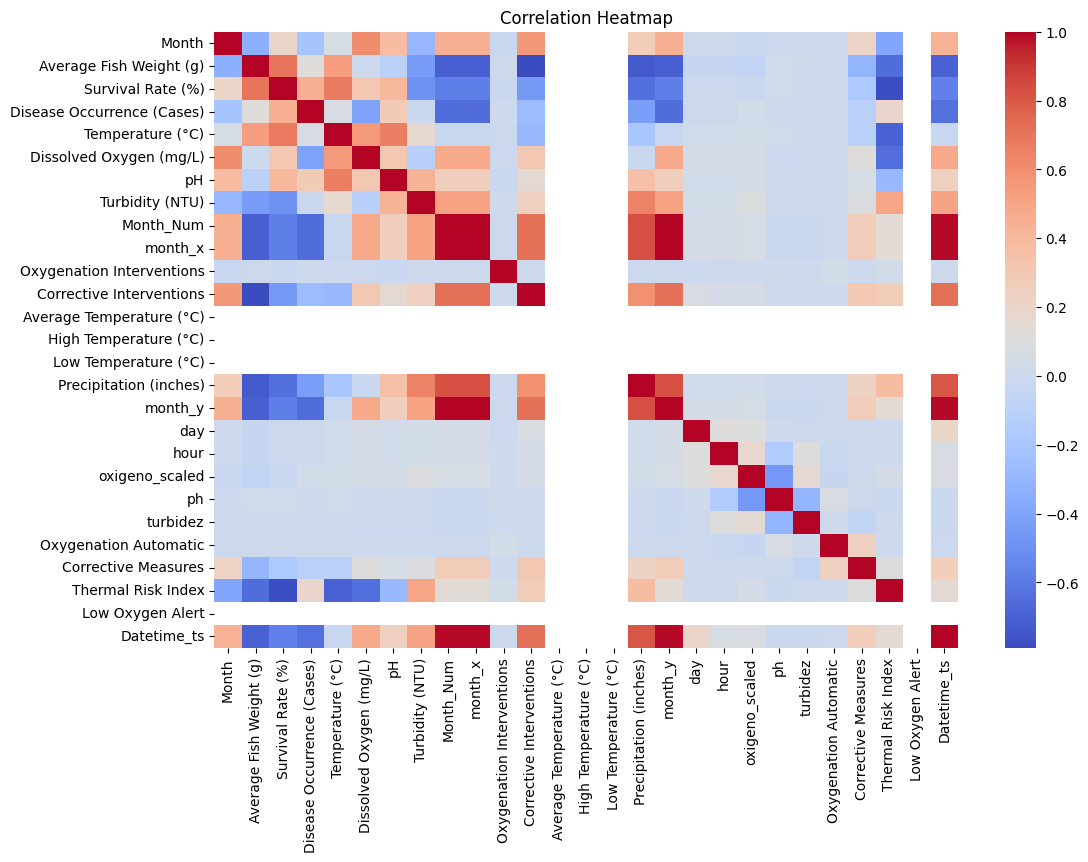

In [44]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [45]:
joblib.dump(
    rf,
    "random_forest_iot.pkl"
)

print("Model Saved")

Model Saved


In [46]:
joblib.dump(
    encoders,
    "encoders.pkl"
)

print("Encoder Saved")

Encoder Saved


In [47]:
print(X.columns.tolist())

['Month', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Month_Num', 'month_x', 'Oxygenation Interventions', 'Corrective Interventions', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 'Precipitation (inches)', 'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Oxygenation Automatic', 'Corrective Measures', 'Thermal Risk Index', 'Low Oxygen Alert', 'Datetime_ts']


In [48]:
print("Accuracy:", accuracy)
print(scores.mean())

print(
    importance.head(10)
)

Accuracy: 1.0
1.0
                    Feature  Importance
4          Temperature (°C)    0.202092
24       Thermal Risk Index    0.189071
1   Average Fish Weight (g)    0.163542
2         Survival Rate (%)    0.112224
5   Dissolved Oxygen (mg/L)    0.095656
6                        pH    0.046366
26              Datetime_ts    0.034009
16                  month_y    0.027560
9                   month_x    0.027105
15   Precipitation (inches)    0.026205


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                       Feature  Importance
4             Temperature (°C)    0.202092
24          Thermal Risk Index    0.189071
1      Average Fish Weight (g)    0.163542
2            Survival Rate (%)    0.112224
5      Dissolved Oxygen (mg/L)    0.095656
6                           pH    0.046366
26                 Datetime_ts    0.034009
16                     month_y    0.027560
9                      month_x    0.027105
15      Precipitation (inches)    0.026205
8                    Month_Num    0.023139
0                        Month    0.022491
7              Turbidity (NTU)    0.022325
3   Disease Occurrence (Cases)    0.006627
11    Corrective Interventions    0.001347
19              oxigeno_scaled    0.000186
20                          ph    0.000020
21                    turbidez    0.000014
18                        hour    0.000011
17                         day    0.000010
10   Oxygenation Interventions    0.000002
14        Low Temperature (°C)    0.000000
12    Avera

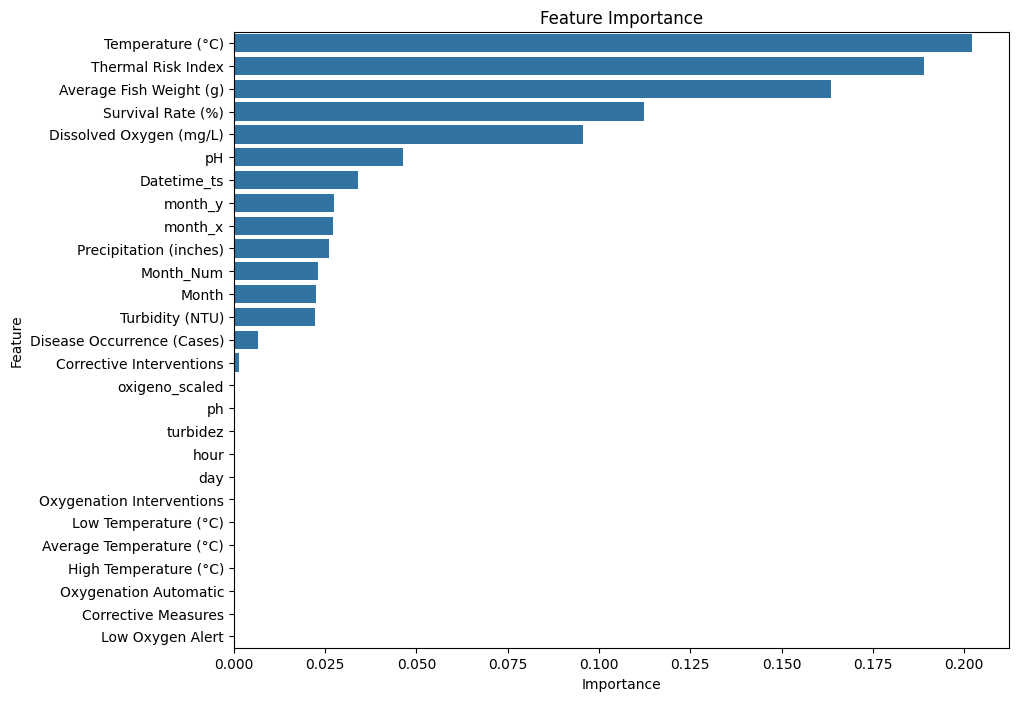

In [50]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [52]:
top_features = (
    importance
    .head(9)["Feature"]
    .tolist()
)

print(top_features)

['Temperature (°C)', 'Thermal Risk Index', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Dissolved Oxygen (mg/L)', 'pH', 'Datetime_ts', 'month_y', 'month_x']


In [53]:
X_selected = X[top_features]

print(X_selected.shape)

(4383, 9)


In [54]:
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_fs = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(
    X_train_fs,
    y_train_fs
)

pred_fs = rf_fs.predict(
    X_test_fs
)

acc_fs = accuracy_score(
    y_test_fs,
    pred_fs
)

print(
    "Accuracy Feature Selection:",
    acc_fs
)

Accuracy Feature Selection: 1.0


In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_fs,
        pred_fs
    )
)

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00       141
      Stable       1.00      1.00      1.00       736

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877

